# Exploratory data analysis: the CNS gold dataset

The basic pass a data scientist makes on an unfamiliar dataset before modelling:
shape and grain, the target, missingness, feature types and scale, redundancy, and the
group structure that dictates how it must be split. Everything here reads only the shipped
`data/gold/` parquet plus its manifest.

*Why* each feature/label exists (sources, leakage tiers) is in `provenance/PROVENANCE.md`;
modelling results are in `models/model_card.md`. This notebook is orientation to the data itself.


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

G = Path('data/gold') if Path('data/gold').exists() else Path('../data/gold')
gold = pd.read_parquet(G / 'cns_cvs_gold_modeling_dataset.parquet')
manifest = pd.read_csv(G / 'cns_cvs_gold_modeling_dataset_manifest.csv')

FEATURE_BLOCKS = ['esmc6b','intrinsic_84','predicted_go','structure','homology']
feature_cols = manifest.loc[manifest.block.isin(FEATURE_BLOCKS), 'column'].tolist()
X = gold[feature_cols]
print('shape:', gold.shape, '\n')
print('columns by role (manifest block):')
print(manifest.block.value_counts().to_string())


shape: (6843, 2735) 

columns by role (manifest block):
block
esmc6b          2560
intrinsic_84      84
predicted_go      61
structure         15
label              5
homology           4
id                 3
fold               3


## 1. Grain: what is a row, and do keys repeat?

A row is a **(gene, indication) pair**. Genes and indications each recur across many rows,
the first thing that decides evaluation: rows are not independent, so cross-validation must
be *grouped* (section 6) or scores will be optimistic.


In [2]:
print('rows (pairs)       :', len(gold))
print('unique genes       :', gold.ensembl_gene_id.nunique())
print('unique indications :', gold.efo_id.nunique())
print('rows per gene      : median %.0f, max %d' % (gold.groupby('ensembl_gene_id').size().median(),
                                                     gold.groupby('ensembl_gene_id').size().max()))
print('duplicate (gene,indication) keys :', int(gold.duplicated(['ensembl_gene_id','efo_id']).sum()))


rows (pairs)       : 6843
unique genes       : 1786
unique indications : 258
rows per gene      : median 2, max 43
duplicate (gene,indication) keys : 0


## 2. The target: definition and class balance

`label_consensus`, 1 = clinically validated, 0 = failed. Strongly imbalanced toward
failures, so headline accuracy is misleading and PR-AUC / precision@k are the metrics that
matter. The other `label_*` columns are confidence aids (tier, per-pair weight, an
efficacy-adjudicated subset), not alternative targets.


failed    (0): 5273 (77.1%)
validated (1): 1570 (22.9%)

auxiliary label columns: ['label_consensus', 'label_consensus_v2', 'label_efficacy_gold', 'label_tier', 'label_confidence']


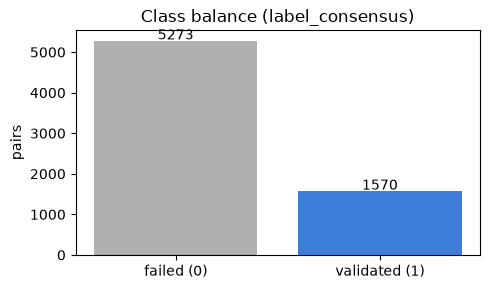

In [3]:
vc = gold.label_consensus.value_counts().sort_index()
print('failed    (0):', int(vc[0.0]), '(%.1f%%)' % (100*vc[0.0]/len(gold)))
print('validated (1):', int(vc[1.0]), '(%.1f%%)' % (100*vc[1.0]/len(gold)))
print('\nauxiliary label columns:', manifest.loc[manifest.block=='label','column'].tolist())

fig, ax = plt.subplots(figsize=(5,3))
ax.bar(['failed (0)','validated (1)'], [vc[0.0], vc[1.0]], color=['#b0b0b0','#3b7dd8'])
ax.set_ylabel('pairs'); ax.set_title('Class balance (label_consensus)')
for i,v in enumerate([vc[0.0],vc[1.0]]): ax.text(i, v+40, f'{int(v)}', ha='center')
plt.tight_layout(); plt.show()


## 3. Missingness: low and structural

Missing values are sparse and occur where a protein genuinely lacks an annotation (e.g. no
solved structure), not at random. That is *missing-not-at-random*: the fact of absence can
itself be weakly informative, so blanket mean-imputation is a modelling choice, not a given.
No imputation is baked into the file.


missing fraction by feature block:
              mean   max
block                   
esmc6b        0.72  0.72
homology      0.70  0.70
intrinsic_84  1.33  5.63
predicted_go  0.89  0.89
structure     1.29  1.33

features with ANY missing value: 2720 of 2724


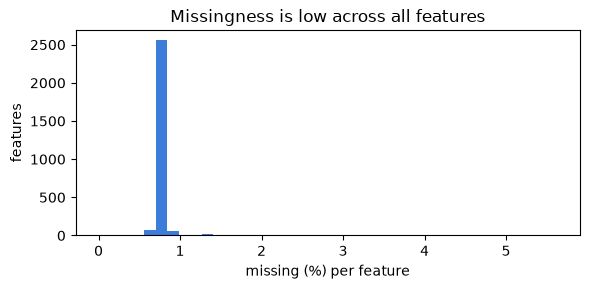

In [4]:
miss = X.isna().mean()
by_block = (manifest.set_index('column').loc[feature_cols, 'block']
            .to_frame().assign(miss=miss.values)
            .groupby('block')['miss'].agg(['mean','max']))
print('missing fraction by feature block:')
print((by_block*100).round(2).to_string())
print('\nfeatures with ANY missing value: %d of %d' % (int((miss>0).sum()), len(feature_cols)))

fig, ax = plt.subplots(figsize=(6,3))
ax.hist(miss.values*100, bins=40, color='#3b7dd8')
ax.set_xlabel('missing (%) per feature'); ax.set_ylabel('features'); ax.set_title('Missingness is low across all features')
plt.tight_layout(); plt.show()


## 4. Feature types and scale

Features are almost all numeric, but on **wildly different scales** (standard deviations span
several orders of magnitude) and a subset are binary indicators. Distance- and gradient-based
models therefore need standardisation; tree ensembles do not. The pipeline standardises
in-fold.


dtypes         : {'float32': 2563, 'float64': 158, 'int64': 2, 'int32': 1}
binary features: 100 | constant: 0
per-feature std ranges from 0.021 to 6.74e+04  (7 orders of magnitude)


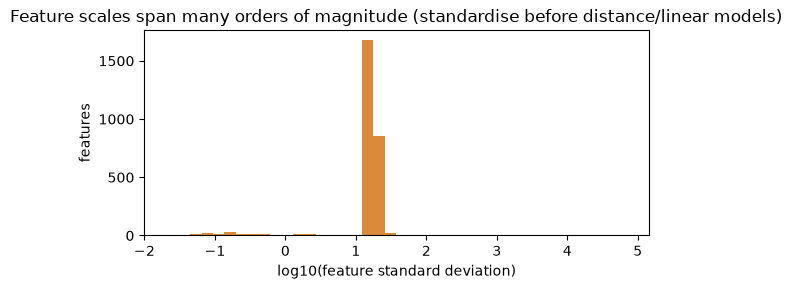

In [5]:
nun = X.nunique()
desc = X.describe().T
print('dtypes         :', X.dtypes.astype(str).value_counts().to_dict())
print('binary features:', int((nun==2).sum()), '| constant:', int((nun<=1).sum()))
print('per-feature std ranges from %.3g to %.3g  (%.0f orders of magnitude)'
      % (desc['std'].min(), desc['std'].max(), np.log10(desc['std'].max()/max(desc['std'].min(),1e-9))))

fig, ax = plt.subplots(figsize=(6,3))
ax.hist(np.log10(desc['std'].clip(lower=1e-3)), bins=40, color='#d98b3b')
ax.set_xlabel('log10(feature standard deviation)'); ax.set_ylabel('features')
ax.set_title('Feature scales span many orders of magnitude (standardise before distance/linear models)')
plt.tight_layout(); plt.show()


## 5. Redundancy: the embedding is high-dimensional but low-rank

The 2,560-dim protein embedding is the bulk of the width, but its variance concentrates in a
few dozen directions. A handful of principal components capture most of it, which is why the
pipeline reduces it to PCA-32 (fit inside each training fold to avoid leakage).


embedding variance explained: 61% by 32 PCs, 69% by 50 PCs


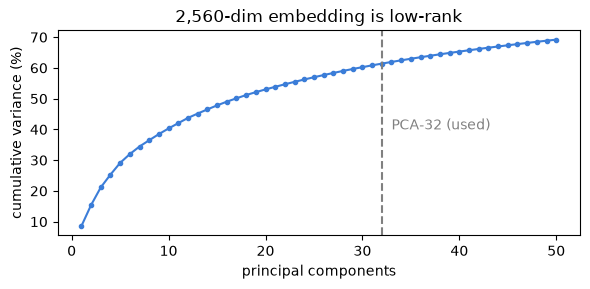

In [6]:
from sklearn.decomposition import PCA
emb = manifest.loc[manifest.block=='esmc6b','column'].tolist()
E = gold[emb].fillna(gold[emb].mean())
pca = PCA(n_components=50, random_state=0).fit(E.values)
cum = np.cumsum(pca.explained_variance_ratio_)
print('embedding variance explained: %.0f%% by 32 PCs, %.0f%% by 50 PCs' % (100*cum[31], 100*cum[49]))

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(range(1,51), cum*100, marker='.', color='#3b7dd8')
ax.axvline(32, ls='--', color='grey'); ax.text(33, 40, 'PCA-32 (used)', color='grey')
ax.set_xlabel('principal components'); ax.set_ylabel('cumulative variance (%)')
ax.set_title('2,560-dim embedding is low-rank'); plt.tight_layout(); plt.show()


## 6. How it must be split: grouped, and frozen

Because genes and indications repeat (section 1), a random split lets a model memorise a gene
in training and be tested on the same gene, inflating scores. Three **frozen** fold columns
ship with the data so everyone uses the identical grouped split:

- **`fold_seqclust`** (primary): whole sequence-similarity clusters held out together, no
  near-homologue leaks across the split. This is the honest number.
- **`fold_gene`**: whole genes held out. **`fold_disease`**: whole indications held out.

Class balance is preserved across folds, and `src/verify_split_lock.py` checks the
`fold_seqclust` fingerprint so the split cannot silently drift.


In [7]:
rows=[]
for f in ['fold_seqclust','fold_gene','fold_disease']:
    for k, sub in gold.groupby(f):
        rows.append((f, int(k), len(sub), sub.label_consensus.mean()))
tab = pd.DataFrame(rows, columns=['fold_col','fold','n','pos_rate'])
print(tab.pivot(index='fold', columns='fold_col', values='n').to_string())
print('\npositive rate per fold stays near the %.1f%% base rate:' % (100*gold.label_consensus.mean()))
print(tab.pivot(index='fold', columns='fold_col', values='pos_rate').round(3).to_string())


fold_col  fold_disease  fold_gene  fold_seqclust
fold                                            
0                  890       1202           1491
1                  878       1374           1214
2                 1222       1521           1291
3                 1997       1342           1368
4                 1856       1404           1479

positive rate per fold stays near the 22.9% base rate:
fold_col  fold_disease  fold_gene  fold_seqclust
fold                                            
0                0.215      0.205          0.278
1                0.364      0.255          0.202
2                0.214      0.236          0.173
3                0.165      0.229          0.202
4                0.252      0.219          0.279


## Takeaways for modelling

1. **Group your CV** by one of the frozen fold columns (`fold_seqclust` by default), never a random split.
2. **Optimise for PR-AUC / precision@k**, not accuracy, the target is ~23% positive.
3. **Standardise in-fold** for linear/distance models; the embedding can be PCA-reduced in-fold.
4. **Decide a missing-value policy** deliberately (absence is weakly informative, not noise).

A complete, tested example that does all of this and reproduces the headline number is
`src/reproduce_headline.py`.
